In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [3]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [4]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [5]:
img

array([[9, 8, 4, 1, 8, 4, 6, 6, 1, 3, 0, 9],
       [8, 3, 3, 9, 6, 3, 7, 6, 7, 3, 1, 7],
       [3, 1, 9, 0, 8, 0, 0, 0, 3, 8, 9, 8],
       [9, 5, 5, 9, 0, 5, 2, 0, 4, 7, 0, 1],
       [5, 2, 8, 4, 2, 1, 2, 8, 3, 6, 2, 1],
       [0, 6, 7, 0, 9, 1, 4, 7, 0, 3, 2, 6],
       [2, 5, 2, 4, 8, 3, 1, 4, 8, 8, 5, 9],
       [3, 9, 6, 3, 8, 2, 8, 7, 3, 8, 6, 3],
       [4, 0, 3, 4, 3, 5, 8, 6, 2, 5, 6, 6],
       [9, 7, 8, 3, 8, 2, 5, 0, 6, 0, 3, 2],
       [2, 1, 3, 2, 8, 0, 7, 3, 3, 4, 5, 8],
       [3, 5, 0, 8, 9, 0, 8, 4, 0, 6, 3, 8]])

In [6]:
h,w=img.shape

In [7]:
print(h,w)

12 12


In [8]:
#[*range(-2,3)]

In [21]:
dst = np.zeros((h,w),np.int)

AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [11]:
img

array([[9, 8, 4, 1, 8, 4, 6, 6, 1, 3, 0, 9],
       [8, 3, 3, 9, 6, 3, 7, 6, 7, 3, 1, 7],
       [3, 1, 9, 0, 8, 0, 0, 0, 3, 8, 9, 8],
       [9, 5, 5, 9, 0, 5, 2, 0, 4, 7, 0, 1],
       [5, 2, 8, 4, 2, 1, 2, 8, 3, 6, 2, 1],
       [0, 6, 7, 0, 9, 1, 4, 7, 0, 3, 2, 6],
       [2, 5, 2, 4, 8, 3, 1, 4, 8, 8, 5, 9],
       [3, 9, 6, 3, 8, 2, 8, 7, 3, 8, 6, 3],
       [4, 0, 3, 4, 3, 5, 8, 6, 2, 5, 6, 6],
       [9, 7, 8, 3, 8, 2, 5, 0, 6, 0, 3, 2],
       [2, 1, 3, 2, 8, 0, 7, 3, 3, 4, 5, 8],
       [3, 5, 0, 8, 9, 0, 8, 4, 0, 6, 3, 8]])

In [17]:
dst

array([[  1,   0, 253, ...,   6,  10,  11],
       [  1,   0, 253, ...,   6,  10,  11],
       [  1,   0, 253, ...,   6,  10,  11],
       ...,
       [251,   6,   1, ...,  14,  13, 251],
       [247,   1, 252, ...,   7,   3, 248],
       [245,  19, 252, ..., 254,   3,   3]], dtype=uint8)

In [13]:
img = cv2.imread('lena.png', 0)

In [14]:
h,w=img.shape

In [15]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [16]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [18]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

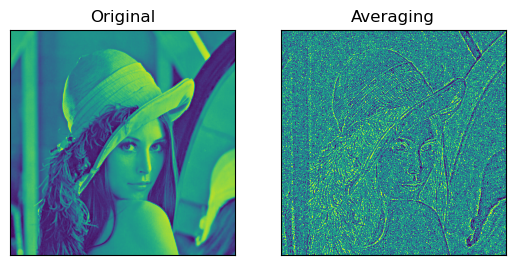

In [19]:
kernel = np.ones((5,5),np.float32)/25
plt.subplot(121),plt.imshow(img),plt.title('Original')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]),plt.yticks([])
plt.show()